## **Show-Reduced-Search-Space-After-Refinement**

In this notebook generate plots which show the reduced search space after library refinement. Only do OpenSWATH because these are quite similar.

In [3]:
import pandas as pd
import polars as pl
from collections import defaultdict
import sys

import matplotlib as mpl
from matplotlib.patches import Patch
import matplotlib.pyplot as plt

In [4]:
print("Pandas Version", pd.__version__)
print("Polars Version", pl.__version__)
print("matplotlib version", mpl.__version__)
print("Python Version", sys.version)

Pandas Version 2.2.3
Polars Version 1.28.1
matplotlib version 3.10.0
Python Version 3.12.4 (main, Jun  7 2024, 23:47:47) [GCC 13.3.0]


#### **Functions**

In [5]:
def getCompressedTSVLibPrecursors(fIn, charge='PrecursorCharge', seq='ModifiedPeptideSequence', compression='zstd'):
    print(fIn)
    lib = pd.read_csv(fIn, sep='\t', compression=compression, usecols=[charge, seq])
    lib['Precursor'] = lib[seq] + lib[charge].astype(str)
    return set(lib['Precursor'])

def getParquetLibPrecursors(fIn):
    print(fIn)
    return set(pl.scan_parquet(fIn).select('Precursor.Id').unique().collect().to_series())

#### **OpenSWATH**

In [9]:
names = dict(exp='Experimental',
             silico='in-silico',
             bruker='timsTOF, 2024',
             panhuman='PanHuman, 2014',
             diatracer='Direct')

conditions = dict(orig='Initial', refined='Reconstructed')

In [10]:
libs = defaultdict(dict)

libs[names['silico']][conditions['orig']] = getCompressedTSVLibPrecursors("../../results/PeptDeep-NoMods-In-Silico-Library-Generation/2025-06-10-in-silico-lib-no-mods_fix_mods_filtered.tsv", compression=None)
libs[ names['silico']][conditions['refined']] = getCompressedTSVLibPrecursors("../../results/K562-PeptDeep-NoMods-Lib-Refined-GPF-Analysis/formattedLib_osw/2025-07-11-osw-peptdeepNoMods-gpf-refined_osw_4_6Frags.tsv", compression=None)

libs[names['bruker']][conditions['orig']] = getCompressedTSVLibPrecursors("../../data/BrukerLibrary/_ip2_ip2_data_paser_spectral_library__Bruker_Human.tsv", compression=None)
libs[names['bruker']][conditions['refined']] = getCompressedTSVLibPrecursors("../../results/K562-Bruker-Lib-Refined-GPF-Analysis/formattedLib_osw/2025-07-10-osw-bruker-gpf-refined_osw_4_6Frags.tsv", compression=None)

libs[names['panhuman']][conditions['orig']] = getCompressedTSVLibPrecursors("../../results/PanHuman-Library-Creation/phl004_s32_imAppended_fixed_diann.tsv", compression=None)
libs[names['panhuman']][conditions['refined'] ] = getCompressedTSVLibPrecursors("../../results/K562-PanHuman-Lib-Refined-GPF-Analysis/formattedLib_osw/2025-06-24-PanHuman-GPF-Refined-OSW_osw_4_6Frags.tsv", compression=None)

libs[names['exp']][conditions['orig']] = getCompressedTSVLibPrecursors("../../results/K562-Library-Generation/easypqp_lib_openswath.tsv", compression=None)
libs[names['exp']][conditions['refined']] = getCompressedTSVLibPrecursors("../../results/K562-Exp-Lib-Refined-GPF-Analysis/formattedLib_osw/2025-03-07-OSW-GPF-Lib_osw_4_6Frags.tsv.zst")

../../results/PeptDeep-NoMods-In-Silico-Library-Generation/2025-06-10-in-silico-lib-no-mods_fix_mods_filtered.tsv
../../results/K562-PeptDeep-NoMods-Lib-Refined-GPF-Analysis/formattedLib_osw/2025-07-11-osw-peptdeepNoMods-gpf-refined_osw_4_6Frags.tsv
../../data/BrukerLibrary/_ip2_ip2_data_paser_spectral_library__Bruker_Human.tsv
../../results/K562-Bruker-Lib-Refined-GPF-Analysis/formattedLib_osw/2025-07-10-osw-bruker-gpf-refined_osw_4_6Frags.tsv
../../results/PanHuman-Library-Creation/phl004_s32_imAppended_fixed_diann.tsv
../../results/K562-PanHuman-Lib-Refined-GPF-Analysis/formattedLib_osw/2025-06-24-PanHuman-GPF-Refined-OSW_osw_4_6Frags.tsv
../../results/K562-Library-Generation/easypqp_lib_openswath.tsv
../../results/K562-Exp-Lib-Refined-GPF-Analysis/formattedLib_osw/2025-03-07-OSW-GPF-Lib_osw_4_6Frags.tsv.zst


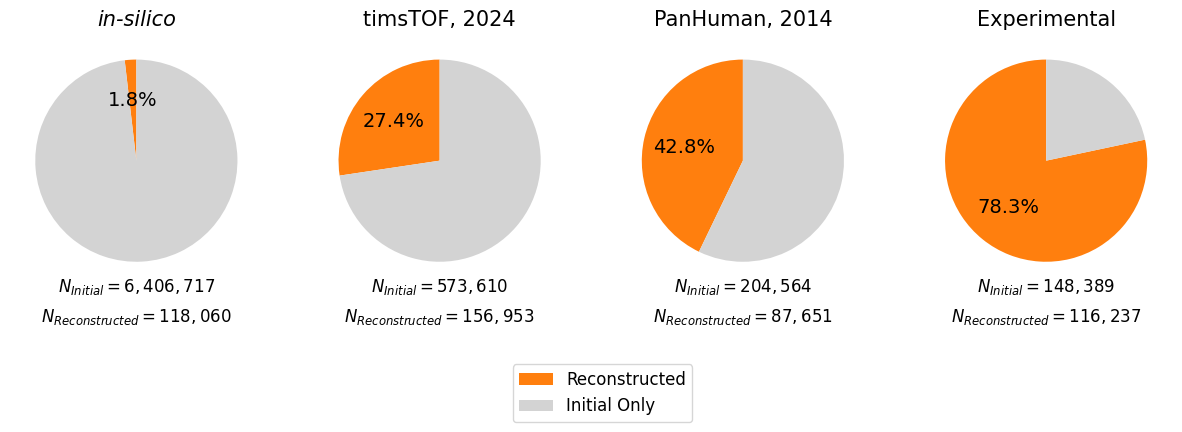

In [11]:
def autopct_only_first(pct):
    return f"{pct:.1f}%" if pct > 0 else ""

def create_pie(A,B, ax, title=None, labels=None, epsilon=0.001, **kwargs):
    assert len(B.intersection(A)) == len(B) # B is a subset of A


    in_B = len(B)
    only_A = len(A - B)

    sizes = [in_B, only_A]

    #ax.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)
    ax.pie(sizes, labels=labels, autopct=lambda pct: autopct_only_first(pct) if abs(pct - sizes[0] / sum(sizes) * 100) < epsilon else "", startangle=90, textprops = dict(fontsize=14), **kwargs)
    ax.text(0,-1.3, f'$N_{{Initial}} = {len(A):,}$', ha='center', fontsize='large')
    ax.text(0,-1.6, f'$N_{{Reconstructed}} = {len(B):,}$', ha='center', fontsize='large')

    ax.set_title(title)


fig, ax = plt.subplots(1,4, figsize=(15,15))
colors = ["#ff7f0e", 'lightgray']  # blue for subset, orange for remainder

for idx, i in enumerate([names['silico'], names['bruker'], names['panhuman'], names['exp']]):
    create_pie(libs[i][conditions['orig']], libs[i][conditions['refined']], ax=ax[idx], title=i, labels=['', ''], colors=colors)
    if i == 'in-silico':
        ax[idx].set_title(i, fontstyle='italic')

    ax[idx].set_title(i, fontsize=15)

 # Custom legend with fixed labels
legend_elements = [
        Patch(facecolor=colors[0], label="Reconstructed"),
        Patch(facecolor=colors[1], label="Initial Only"),
    ]
fig.legend(
        handles=legend_elements,
        loc="center",
        bbox_to_anchor = (0.52,0.34),
        fontsize='large'
    )

fig.savefig("Figure-S7.png", dpi=400, bbox_inches='tight')